# Lab 5 - Advanced architectures and NLP techniques

NLP combines linguistics, computer science, and machine learning to enable computers to understand, interpret, and generate human language.

## How to do a sentiment analysis

We will use the `spaCy` library to perform sentiment analysis on a twitter dataset.

In [58]:
import opendatasets as od
import pandas as pd
pd.set_option('display.max_colwidth', None)
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import spacy
import nltk
from nltk.corpus import stopwords
from wordcloud import WordCloud
import re
import gensim.downloader
from gensim.models import Word2Vec
from gensim.parsing.preprocessing import preprocess_string
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Input, Dense, Dropout, Embedding, Flatten, LSTM
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.preprocessing.text import Tokenizer
from transformers import BertTokenizer, TFBertModel
from sklearn.model_selection import train_test_split
from scipy.special import softmax

# uv run python -m spacy download en_core_web_sm
nlp = spacy.load("en_core_web_sm")
nltk.download('vader_lexicon')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('punkt')
nltk.download('punkt_tab')

[nltk_data] Downloading package vader_lexicon to
[nltk_data]     /home/javier/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!
[nltk_data] Downloading package stopwords to /home/javier/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /home/javier/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt to /home/javier/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /home/javier/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

## 1. Loading the dataset

We will use the ["Twitter Sentiment Analysis Dataset"](https://www.kaggle.com/datasets/jp797498e/twitter-entity-sentiment-analysis).

This is an entity-level sentiment analysis dataset of twitter. Given a message and an entity, the task is to judge the sentiment of the message about the entity. There are three classes in this dataset: Positive, Negative and Neutral. We regard messages that are not relevant to the entity (i.e. Irrelevant) as Neutral.

In [59]:
columns = ['id', 'category', 'label', 'text']
training_data = pd.read_csv('datasets/twitter-sentiment-analysis/twitter_training.csv', names=columns)
validation_data = pd.read_csv('datasets/twitter-sentiment-analysis/twitter_validation.csv', names=columns)


In [60]:
training_data.sample(5)

,id,category,label,text
22893,4323,CS-GO,Neutral,bruh i haven't played csgo for about a week wtf
38946,5485,Hearthstone,Positive,Come help make an OTK Priest tonight at 9:30pm MST. It is going to be a ton of fun! Don’t miss out!. twitch.tv/HellsF1rst. . fb.me/e/fj0rQWF02. .
45162,11755,Verizon,Neutral,"OneSearch, Verizon Media’s new search engine, sounds awfully familiar dlvr.it/RNFth4 https://t.co/Imf8rzmzCc"
47212,5700,HomeDepot,Positive,2015 Great honor by Frazer Home Depot & RhandlerR to remember our Vets. pic.twitter.com/aQrDJA7ilJ
19753,12581,WorldOfCraft,Positive,I laughed so much at it.


In [61]:
print(f"Training data shape: {training_data.shape}, Test data shape: {validation_data.shape}")

Training data shape: (74682, 4), Test data shape: (1000, 4)


In [62]:
training_data = training_data.drop(['id'], axis=1)
validation_data = validation_data.drop(['id'], axis=1)

We don't need ID for un sentiment analysis, so we will drop it from the dataset.

## 2. Analysing the dataset

We will analyse the dataset to understand its structure and content. We will look at the distribution of classes per category.

/tmp/ipykernel_23297/533421140.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(training_data.label, palette='viridis', order=training_data['label'].value_counts().index)


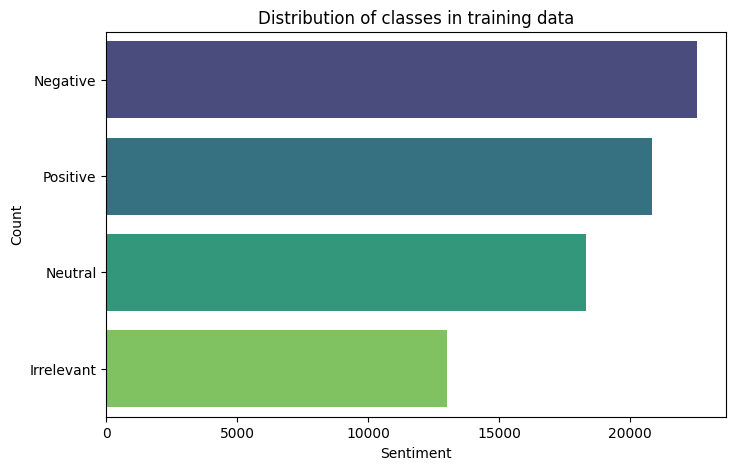

/tmp/ipykernel_23297/533421140.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(training_data.category, palette='viridis', order=training_data['category'].value_counts().index)


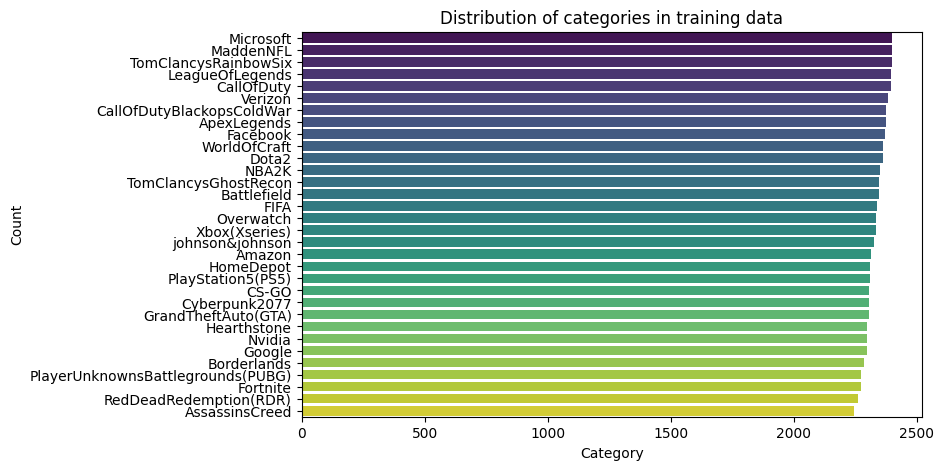

([0,
  1,
  2,
  3,
  4,
  5,
  6,
  7,
  8,
  9,
  10,
  11,
  12,
  13,
  14,
  15,
  16,
  17,
  18,
  19,
  20,
  21,
  22,
  23,
  24,
  25,
  26,
  27,
  28,
  29,
  30,
  31],
 [Text(0, 0, 'Borderlands'),
  Text(1, 0, 'CallOfDutyBlackopsColdWar'),
  Text(2, 0, 'Amazon'),
  Text(3, 0, 'Overwatch'),
  Text(4, 0, 'Xbox(Xseries)'),
  Text(5, 0, 'NBA2K'),
  Text(6, 0, 'Dota2'),
  Text(7, 0, 'PlayStation5(PS5)'),
  Text(8, 0, 'WorldOfCraft'),
  Text(9, 0, 'CS-GO'),
  Text(10, 0, 'Google'),
  Text(11, 0, 'AssassinsCreed'),
  Text(12, 0, 'ApexLegends'),
  Text(13, 0, 'LeagueOfLegends'),
  Text(14, 0, 'Fortnite'),
  Text(15, 0, 'Microsoft'),
  Text(16, 0, 'Hearthstone'),
  Text(17, 0, 'Battlefield'),
  Text(18, 0, 'PlayerUnknownsBattlegrounds(PUBG)'),
  Text(19, 0, 'Verizon'),
  Text(20, 0, 'HomeDepot'),
  Text(21, 0, 'FIFA'),
  Text(22, 0, 'RedDeadRedemption(RDR)'),
  Text(23, 0, 'CallOfDuty'),
  Text(24, 0, 'TomClancysRainbowSix'),
  Text(25, 0, 'Facebook'),
  Text(26, 0, 'GrandTheftAu

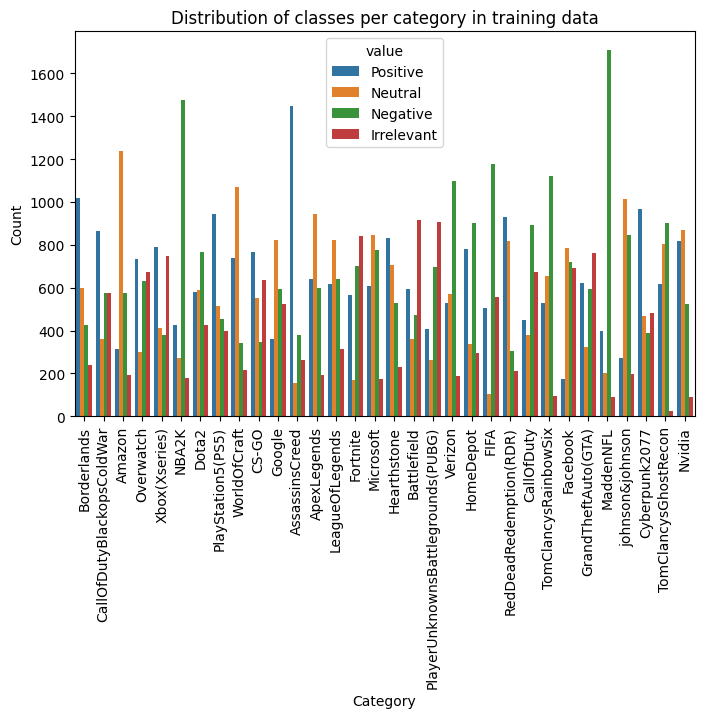

In [63]:
plt.figure(figsize=(8,5))
sns.countplot(training_data.label, palette='viridis', order=training_data['label'].value_counts().index)
plt.title('Distribution of classes in training data')
plt.xlabel('Sentiment')
plt.ylabel('Count')
plt.show()

plt.figure(figsize=(8,5))
sns.countplot(training_data.category, palette='viridis', order=training_data['category'].value_counts().index)
plt.title('Distribution of categories in training data')
plt.xlabel('Category')
plt.ylabel('Count')
plt.show()

plt.figure(figsize=(8,5))
sns.countplot(data=pd.melt(training_data, id_vars=['category'], value_vars=['label'], var_name='label'), x='category', hue='value')
plt.title('Distribution of classes per category in training data')
plt.xlabel('Category')
plt.ylabel('Count')
plt.xticks(rotation=90)

Negative and Positive sentiments are similar in size, neutral and irelevant are smaller but we won't use them for the analysis.

## 3. Preprocessing the data

We will preprocess the data to prepare it for training. This includes removing stop words, punctuation, special characters, and removing URLs and mentions.

In [ ]:
def clean_tweet(text):
    # To string
    text = str(text)

    # Remove URLs
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)

    # Remove user @ references and '#' from hashtags
    text = re.sub(r'\@\w+|\#','', text)

    # Remove special characters, numbers, punctuations (except for apostrophes)
    text = re.sub(r"[^a-zA-Z']", ' ', text)

    # Remove RT (retweet)
    text = re.sub(r'\bRT\b', '', text)

    # Replace contractions
    contractions = {
        "ain't": "is not",
        "aren't": "are not",
        "can't": "cannot",
        "'cause": "because",
        "could've": "could have",
        "won't": "will not",
        "wouldn't": "would not",
        "didn't": "did not",
        "doesn't": "does not",
        "don't": "do not",
        "it's": "it is",
        "i'm": "I am",
        "they're": "they are",
        "we're": "we are",
        "you're": "you are",
        "that's": "that is",
        "there's": "there is",
        "what's": "what is",
        "who's": "who is",
        "couldn't": "could not",
        "shouldn't": "should not",
        "would've": "would have",
        "let's": "let us",
        "imma": "I am going to",
        "im": "I am",
        "Im": "I am",
        "n't": " not",
        "'re": " are",
        "'ve": " have",
        "'ll": " will",
        "'d": " would",
        "'s": " is",
        "'t": " not",
        "'m": " am",
    }
    for contraction, replacement in contractions.items():
        text = re.sub(r'\b' + re.escape(contraction) + r'\b', replacement, text, flags=re.IGNORECASE)

    # Remove extra spaces and lowercase
    text = re.sub(r'\s+', ' ', text).strip().lower()

    # Remove stop words (Stop words are common words that do not add much meaning to a sentence, such as "i", "me", "myself", etc.)
    stop_words = set(stopwords.words('english'))
    tweet_tokens = nltk.word_tokenize(text)
    filtered_words = [word for word in tweet_tokens if word not in stop_words]
    text = ' '.join(filtered_words)

    # Lemmatization (Lemmatization is commented out to speed up preprocessing. Basically what it does is to reduce words to their base form, for example "running" becomes "run")
    # doc = nlp(text)
    # lemmatized_words = [token.lemma_ for token in doc]
    # text = ' '.join(lemmatized_words)

    return text

This cleaning if for tweets, other types of text may require different preprocessing steps.

In [65]:
training_data['clean_text'] = training_data['text'].apply(clean_tweet)
validation_data['clean_text'] = validation_data['text'].apply(clean_tweet)

In [66]:
training_data.sample(5)

,category,label,text,clean_text
5662,Amazon,Neutral,"Amazon Select Great Indian For Sale : I Get Rs 15, 000 Amazon Pay Cashback With buying a New York OnePlus for TV.. Read more reviews at OursWideWeb. com x https://t.co/ipKtVWUYQ3 ]",amazon select great indian sale get rs amazon pay cashback buying new york oneplus tv read reviews ourswideweb com x
69822,Cyberpunk2077,Positive,I want to play Cyberpunk 2077 right now so bad AAAAAAAAAAAAA,want play cyberpunk right bad aaaaaaaaaaaaa
60462,Facebook,Irrelevant,Good catch! Disgusting trumps! They belong with other racists. @realDonaldTrump @DonaldJTrumpJr @IvankaTrump @EricTrump,good catch disgusting trumps belong racists
12666,NBA2K,Neutral,@isaiahthomas another one with my guy! @Ronnie2K @NBA2K_MyTEAM @NBA2K 70 points this time!! Drop a Sim for the people who haven’t collected 750 cards!! pic.twitter.com/hNngXvDmCr,another one guy points time drop sim people collected cards pic twitter com hnngxvdmcr
42656,PlayerUnknownsBattlegrounds(PUBG),Negative,"@ PUBGMOE the shit game can't even play a single match because of its high ping, rolling and many other problems.",pubgmoe shit game even play single match high ping rolling many problems


In [67]:
training_data.to_csv('datasets/twitter-sentiment-analysis/twitter_training_cleaned.csv', index=False)
validation_data.to_csv('datasets/twitter-sentiment-analysis/twitter_validation_cleaned.csv', index=False)

In [68]:
training_data = pd.read_csv('datasets/twitter-sentiment-analysis/twitter_training_cleaned.csv')
validation_data = pd.read_csv('datasets/twitter-sentiment-analysis/twitter_validation_cleaned.csv')

In [69]:
# print null values
print(f"Training data null values:\n{training_data.isnull().sum()}")
print(f"Validation data null values:\n{validation_data.isnull().sum()}")

training_data = training_data.dropna()
validation_data = validation_data.dropna()

Training data null values:
category         0
label            0
text           686
clean_text    2429
dtype: int64
Validation data null values:
category      0
label         0
text          0
clean_text    1
dtype: int64


## 4. Wordclouds

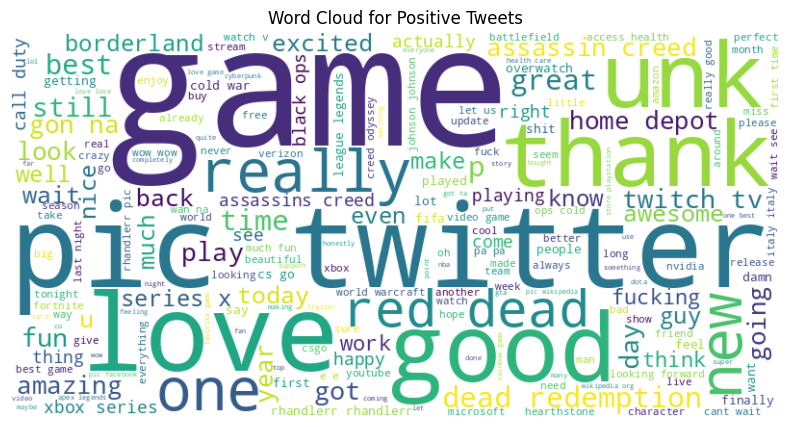

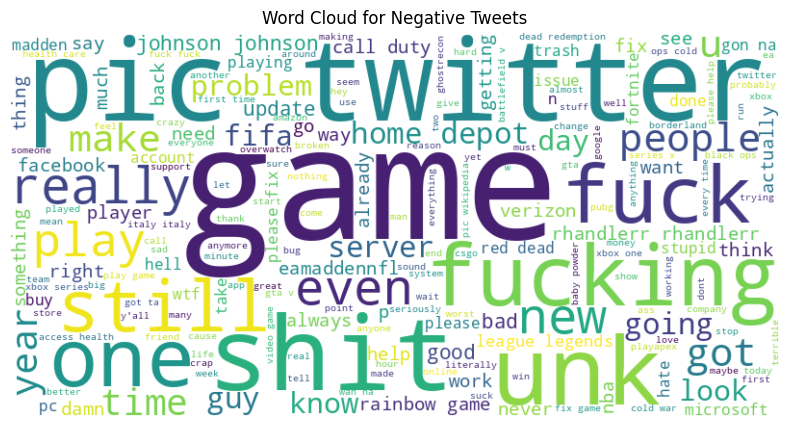

In [70]:
for label in ['Positive', 'Negative']:
    plt.figure(figsize=(10,5))
    text = ' '.join(training_data[training_data['label'] == label]['clean_text'])
    wordcloud = WordCloud(width=800, height=400, background_color='white').generate(text)
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.title(f'Word Cloud for {label} Tweets')
    plt.axis('off')
    plt.show()

For positive tweets we can see words like "love", "great", "good", while for negative tweets we see words like "shit", "fuck", "fucking". This gives us an idea of the common words used in each sentiment category.

## 5. Word embeddings

We will use two types of word embeddings: Word2Vec and TF-IDF. This is required to convert the text data into numerical format that can be used by machine learning algorithms.

### 5.1 Bag of Words (BoW)

Measure the frequency of each word in the document. Each unique word in the document is represented as a feature, and the value of each feature is the count of occurrences of that word in the document.

Example:
corpus = [
    "This is the first document.",
    "This document is the second document.",
]

Output: ['this', 'is', 'the', 'first', 'document', 'second']

[[1 1 1 1 1 0],

 [1 1 1 0 2 1]]

In [71]:
corpus = [
    "This is the first document.",
    "This document is the second document.",
    "And this is the third one.",
    "Is this the first document?",
]
vectorizer = CountVectorizer()
X = vectorizer.fit_transform(corpus)
print("Feature names:\n", vectorizer.get_feature_names_out())
print("Bag of Words representation:\n", X.toarray())

Feature names:
 ['and' 'document' 'first' 'is' 'one' 'second' 'the' 'third' 'this']
Bag of Words representation:
 [[0 1 1 1 0 0 1 0 1]
 [0 2 0 1 0 1 1 0 1]
 [1 0 0 1 1 0 1 1 1]
 [0 1 1 1 0 0 1 0 1]]


In [72]:
count_vectorizer = CountVectorizer()
X_train_bow = count_vectorizer.fit_transform(training_data['clean_text'])
print(f"Bag of Words shape: {X_train_bow.shape}")
print(f"Tweet: {training_data.clean_text[50]} -> BoW vector: {X_train_bow[50]}")

Bag of Words shape: (72253, 29120)
Tweet: guilty sobriety bit borderline called work early tomorrow catch -> BoW vector: <Compressed Sparse Row sparse matrix of dtype 'int64'
	with 18 stored elements and shape (1, 29120)>
  Coords	Values
  (0, 2815)	1
  (0, 15174)	1
  (0, 25456)	1
  (0, 10442)	1
  (0, 25629)	1
  (0, 2513)	1
  (0, 22793)	1
  (0, 24746)	1
  (0, 14609)	1
  (0, 2431)	1
  (0, 3409)	1
  (0, 7335)	1
  (0, 28150)	1
  (0, 23429)	1
  (0, 14869)	1
  (0, 26179)	1
  (0, 26139)	1
  (0, 19763)	1


### 5.2 TF-IDF

Weighs the frequency of a word in a document against its frequency across all documents. This helps to highlight words that are more important in a specific document while down-weighting common words that appear frequently across all documents.

In [73]:
corpus = [
    "This is the first document.",
    "This document is the second document.",
    "And this is the third one.",
    "Is this the first document?",
]
vectorizer = TfidfVectorizer()
X = vectorizer.fit_transform(corpus)
print("Feature names:\n", vectorizer.get_feature_names_out())
print("TF-IDF representation:\n", X.toarray())

Feature names:
 ['and' 'document' 'first' 'is' 'one' 'second' 'the' 'third' 'this']
TF-IDF representation:
 [[0.         0.46979139 0.58028582 0.38408524 0.         0.
  0.38408524 0.         0.38408524]
 [0.         0.6876236  0.         0.28108867 0.         0.53864762
  0.28108867 0.         0.28108867]
 [0.51184851 0.         0.         0.26710379 0.51184851 0.
  0.26710379 0.51184851 0.26710379]
 [0.         0.46979139 0.58028582 0.38408524 0.         0.
  0.38408524 0.         0.38408524]]


In [74]:
count_vectorizer = TfidfVectorizer()
X_train_bow = count_vectorizer.fit_transform(training_data['clean_text'])
print(f"TF-IDF shape: {X_train_bow.shape}")
print(f"Tweet: {training_data.clean_text[50]} -> TF-IDF vector: {X_train_bow[50]}")

TF-IDF shape: (72253, 29120)
Tweet: guilty sobriety bit borderline called work early tomorrow catch -> TF-IDF vector: <Compressed Sparse Row sparse matrix of dtype 'float64'
	with 18 stored elements and shape (1, 29120)>
  Coords	Values
  (0, 2815)	0.17175700944569464
  (0, 15174)	0.16535347797863764
  (0, 25456)	0.14533447599562155
  (0, 10442)	0.1515378478361054
  (0, 25629)	0.2172431098501562
  (0, 2513)	0.32888770791248856
  (0, 22793)	0.29832674770353884
  (0, 24746)	0.37203602457260576
  (0, 14609)	0.199514558088313
  (0, 2431)	0.19260818082873277
  (0, 3409)	0.2218697668590565
  (0, 7335)	0.2310164700925027
  (0, 28150)	0.17613307200291903
  (0, 23429)	0.21290954571070106
  (0, 14869)	0.27017188348324317
  (0, 26179)	0.16923207374467372
  (0, 26139)	0.16144634407342381
  (0, 19763)	0.3643503977981069


### 5.3 Word2Vec and GloVe

Word2Vec and GloVe are advanced word embedding techniques that capture semantic relationships between words by representing them in a continuous vector space. These embeddings can be pre-trained on large corpora and fine-tuned for specific tasks (they use neural networks to learn word associations from a large corpus of text.)

> They use the hypothesis that words used in similar contexts tend to have similar meanings.

In [75]:
texts = training_data['clean_text'].apply(preprocess_string).tolist()
word2vec_model = Word2Vec(sentences=texts, vector_size=100, window=5, min_count=1, workers=1)
word2vec_model.save("models/word2vec_twitter.model")

> Window size: The number of words to consider to the left and right of the target word.

> Vector size: The dimensionality of the word vectors. That is, how many features each word vector will have.

In [76]:
word_vectors = word2vec_model.wv
similarity = word_vectors.similarity('clear', 'light')
print(f"Similarity between 'clear' and 'light': {similarity}")

similarity = word_vectors.similarity('good', 'great')
print(f"Similarity between 'good' and 'great': {similarity}")

similarity = word_vectors.similarity('fuck', 'shit')
print(f"Similarity between 'fuck' and 'shit': {similarity}")

similarity = word_vectors.similarity('hate', 'love')
print(f"Similarity between 'hate' and 'love': {similarity}")

Similarity between 'clear' and 'light': 0.9130489230155945
Similarity between 'good' and 'great': 0.7952394485473633
Similarity between 'fuck' and 'shit': 0.9049707055091858
Similarity between 'hate' and 'love': 0.40445658564567566


Let's find the 10 most similar words to "hate" in our trained model

In [77]:
try:
    similar_words = word_vectors.most_similar('hate', topn=10)
    print("5 most similar words to 'hate':")
    for word, similarity in similar_words:
        print(f"{word}: {similarity}")
except KeyError:
    print("The word 'hate' is not in the vocabulary.")

5 most similar words to 'hate':
wrong: 0.8515113592147827
backkkkkkk: 0.8462985157966614
bbhl: 0.8451213836669922
throw: 0.8440747261047363
laredo: 0.8438704013824463
ppl: 0.8410810828208923
joke: 0.8382706046104431
stupid: 0.8371149897575378
kbm: 0.8359637260437012
sympathi: 0.8358834981918335


> The cosine similarity measures the cosine of the angle between two non-zero vectors in an inner product space. It is a measure of similarity between two vectors, ranging from -1 (completely dissimilar) to 1 (completely similar).

> Some words similar to "hate" are "wrong", "stupid", "joke" given our Twitter dataset. Other words may not make sense because of the preprocessing steps we applied (removing punctuation, lowercasing, etc.)

### 5.3.1 GloVe

The library GeSim provides pre-trained GloVe embeddings that can be used for various NLP tasks. These embeddings are trained on large corpora and capture semantic relationships between words.

In [78]:
glove_vector = gensim.downloader.load("glove-twitter-25")

try:
    similar_words = glove_vector.most_similar('hate', topn=5)
    print("5 most similar words to 'hate':")
    for word, similarity in similar_words:
        print(f"{word}: {similarity}")
except KeyError:
    print("The word 'hate' is not in the vocabulary.")

5 most similar words to 'hate':
think: 0.9363393187522888
why: 0.9351921081542969
stupid: 0.9348065257072449
reason: 0.9329289793968201
either: 0.9328351020812988


Glove is similar to Word2Vec but it uses a different approach to learn word embeddings by factorizing a word co-occurrence matrix. It's a bit better.

## 6. Sentiment analysis

In this section, we will build and evaluate sentiment analysis models using the preprocessed data and word embeddings. We will compare the performance of different models: Feed Forward Neural Network, LSTM (Long Short-Term Memory) and BERT (Bidirectional Encoder Representations from Transformers).

### 6.1 Word2Vec + Feed Forward Neural Network (FFNN)

We will start by filtering only positive and negative tweets. Then we will map them to 1 and 0.

In [79]:
training_data = training_data[training_data["label"].isin(["Positive", "Negative"])]

training_data["label"] = training_data["label"].map({"Positive": 1, "Negative": 0})

y = training_data["label"].values

We will now tokenize the text.

In [81]:
tokenizer = Tokenizer()
tokenizer.fit_on_texts(training_data['clean_text'])
X_sequences = tokenizer.texts_to_sequences(training_data['clean_text'])
X = pad_sequences(X_sequences, maxlen=100)

print(f'Preprocessed text: {training_data["clean_text"][100]}')
print(f'Tokenized text: {X_sequences[100]}')
print(f'Padded sequence: {X[100]}')
print(f'Padded text length: {len(X[100])}')

Preprocessed text: deep grounded almost looked pretty cool even despite borderlands fifth tier unfunny writing format ultimately became yet another survival crafting mobile game really wait shitty trend starting die
Tokenized text: [358, 622, 64, 22, 2912, 1982, 244, 325, 1078, 9, 1669, 1424]
Padded sequence: [   0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0  358  622   64   22 2912 1982  244  325 1078    9
 1669 1424]
Padded text length: 100


> We are padding the sequences to ensure that all input sequences have the same length, which is required for batch processing in neural networks. Here, we are padding the sequences to a maximum length of 100 tokens. If input sequences are shorter than this length, they will be padded with zeros at the beginning. If they are longer, they will be truncated to fit this length.

Now we will create the embedding matrix, which maps each word in the tokenizer's vocabulary to its corresponding Word2Vec vector. This matrix will be used to initialize the embedding layer in our neural network.

In [85]:
embedding_matrix = np.zeros((len(tokenizer.word_index) + 1, 100))
for word, i in tokenizer.word_index.items():
    if word in word_vectors.key_to_index:
        embedding_matrix[i] = word_vectors.get_vector(word)

embedding_matrix

array([[ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00, ...,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
       [ 1.31979454e+00,  1.61096370e+00, -1.43859875e+00, ...,
        -2.77650595e-01,  6.87946081e-01,  1.02186406e+00],
       [ 1.49360251e+00, -1.96039033e+00,  3.50900030e+00, ...,
         5.91570973e-01, -2.13827515e+00, -3.20603281e-01],
       ...,
       [ 1.02348523e-02,  1.60043780e-02,  8.45515262e-03, ...,
        -8.83137342e-03,  6.25068275e-03, -9.18013044e-03],
       [ 1.60237192e-03,  1.13940472e-02, -1.09139727e-02, ...,
         4.09093406e-03, -6.25078508e-04, -6.44754525e-03],
       [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00, ...,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00]],
      shape=(18566, 100))

In [86]:
embedding_matrix.shape

(18566, 100)

We define the FFNN model architecture. The model consists of an embedding layer initialized with the pre-trained Word2Vec embeddings, followed by a flattening layer and an output layer with sigmoid activation for binary classification.

> Close to 1 means positive sentiment, close to 0 means negative sentiment.

In [94]:
model_ffnn = Sequential()
model_ffnn.add(Embedding(len(tokenizer.word_index) + 1, 100, weights=[embedding_matrix], input_length=100, trainable=False))
model_ffnn.add(Flatten())
model_ffnn.add(Dense(1, activation='sigmoid'))

model_ffnn.summary()

/home/javier/Documents/IA/IA learning/lab5/.venv/lib/python3.13/site-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ ?                      │     1,856,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,856,600 (7.08 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 1,856,600 (7.08 MB)

We will use binary crossentropy as the loss function since this is a binary classification problem. And Adam optimizer for optimization.

In [95]:
model_ffnn.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

history_ffnn = model_ffnn.fit(X, y, epochs=5, validation_split=0.2)

Epoch 1/5
1051/1051 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.7130 - loss: 0.5692 - val_accuracy: 0.7037 - val_loss: 0.5762
Epoch 2/5
1051/1051 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.7279 - loss: 0.5452 - val_accuracy: 0.7003 - val_loss: 0.5759
Epoch 3/5
1051/1051 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.7325 - loss: 0.5377 - val_accuracy: 0.7016 - val_loss: 0.5809
Epoch 4/5
1051/1051 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.7363 - loss: 0.5336 - val_accuracy: 0.6879 - val_loss: 0.5849
Epoch 5/5
1051/1051 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.7376 - loss: 0.5298 - val_accuracy: 0.7019 - val_loss: 0.5861


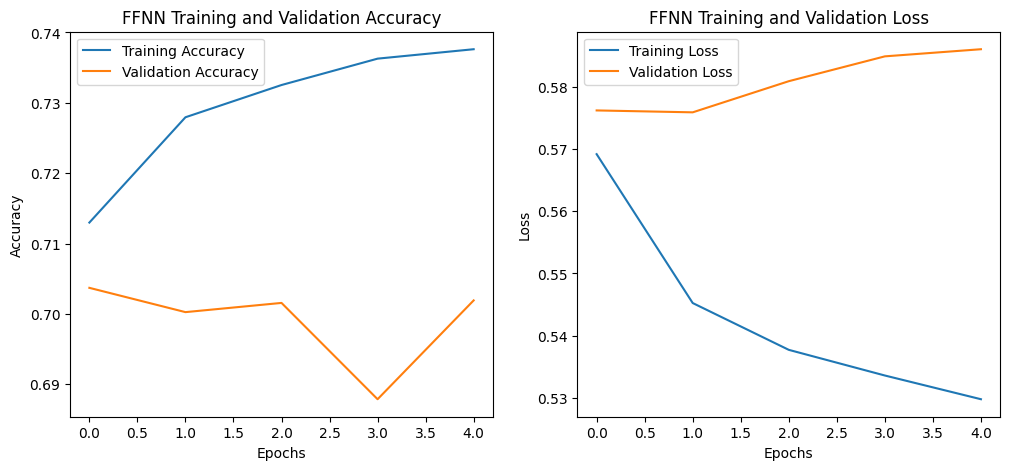

In [96]:
plt.figure(figsize=(12,5))
plt.subplot(1, 2, 1)
plt.plot(history_ffnn.history['accuracy'], label='Training Accuracy')
plt.plot(history_ffnn.history['val_accuracy'], label='Validation Accuracy')
plt.title('FFNN Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_ffnn.history['loss'], label='Training Loss')
plt.plot(history_ffnn.history['val_loss'], label='Validation Loss')
plt.title('FFNN Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.show()

We have a very basic model that achieves around 74% accuracy on the validation set after 5 epochs. Further tuning and more complex architectures could improve performance.

In [98]:
def make_predictions_ffnn(text):
    preprocessed_text = clean_tweet(text)
    sequence = tokenizer.texts_to_sequences([preprocessed_text])
    padded_sequence = pad_sequences(sequence, maxlen=100)
    prediction = model_ffnn.predict(padded_sequence)
    sentiment = 'Positive' if prediction[0][0] >= 0.5 else 'Negative'
    return sentiment, prediction[0][0]

In [99]:
example_tweet = "I love this product! It works great and exceeded my expectations."
sentiment, confidence = make_predictions_ffnn(example_tweet)
print(f"Tweet: {example_tweet}\nPredicted Sentiment: {sentiment} (Confidence: {confidence})")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
Tweet: I love this product! It works great and exceeded my expectations.
Predicted Sentiment: Positive (Confidence: 0.9358887076377869)


In [100]:
example_tweet = "I hate this product! It is terrible and a waste of money."
sentiment, confidence = make_predictions_ffnn(example_tweet)
print(f"Tweet: {example_tweet}\nPredicted Sentiment: {sentiment} (Confidence: {confidence})")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
Tweet: I hate this product! It is terrible and a waste of money.
Predicted Sentiment: Negative (Confidence: 0.3123995363712311)


In [102]:
example_tweet = "I love being scamed by online sellers!"
sentiment, confidence = make_predictions_ffnn(example_tweet)
print(f"Tweet: {example_tweet}\nPredicted Sentiment: {sentiment} (Confidence: {confidence})")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
Tweet: I love being scamed by online sellers!
Predicted Sentiment: Positive (Confidence: 0.8272411227226257)


Positive and negative tweets are predicted correctly by the model (less confidence for negative tweets). However, irony is not detected correctly.

### 6.2 Word2Vec + Sequential LSTM

Texts are sequential data, where the order is important, so we can use LSTM to capture the context and dependencies between words in a tweet.

> Time series data is also sequential, where the order of data points matters. LSTM is commonly used for time series forecasting tasks to capture temporal dependencies and patterns in the data over time.

> Training take longer than FFNN because of the sequential nature of LSTM. And with a lot of data, it can be computationally expensive.

In [103]:
model_lstm = Sequential()
model_lstm.add(Embedding(len(tokenizer.word_index) + 1, 100, weights=[embedding_matrix], input_length=100, trainable=False))
model_lstm.add(LSTM(128))
model_lstm.add(Dense(1, activation='sigmoid'))

model_lstm.summary()

/home/javier/Documents/IA/IA learning/lab5/.venv/lib/python3.13/site-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_4 (Embedding)         │ ?                      │     1,856,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,856,600 (7.08 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 1,856,600 (7.08 MB)

In [104]:
model_lstm.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
history_lstm = model_lstm.fit(X, y, epochs=5, validation_split=0.2)

Epoch 1/5
1051/1051 ━━━━━━━━━━━━━━━━━━━━ 42s 39ms/step - accuracy: 0.7313 - loss: 0.5359 - val_accuracy: 0.7192 - val_loss: 0.5370
Epoch 2/5
1051/1051 ━━━━━━━━━━━━━━━━━━━━ 41s 39ms/step - accuracy: 0.7588 - loss: 0.4933 - val_accuracy: 0.6931 - val_loss: 0.5837
Epoch 3/5
1051/1051 ━━━━━━━━━━━━━━━━━━━━ 41s 39ms/step - accuracy: 0.7773 - loss: 0.4608 - val_accuracy: 0.7091 - val_loss: 0.5677
Epoch 4/5
1051/1051 ━━━━━━━━━━━━━━━━━━━━ 41s 39ms/step - accuracy: 0.8024 - loss: 0.4153 - val_accuracy: 0.7012 - val_loss: 0.6178
Epoch 5/5
1051/1051 ━━━━━━━━━━━━━━━━━━━━ 40s 38ms/step - accuracy: 0.8278 - loss: 0.3667 - val_accuracy: 0.6857 - val_loss: 0.6922


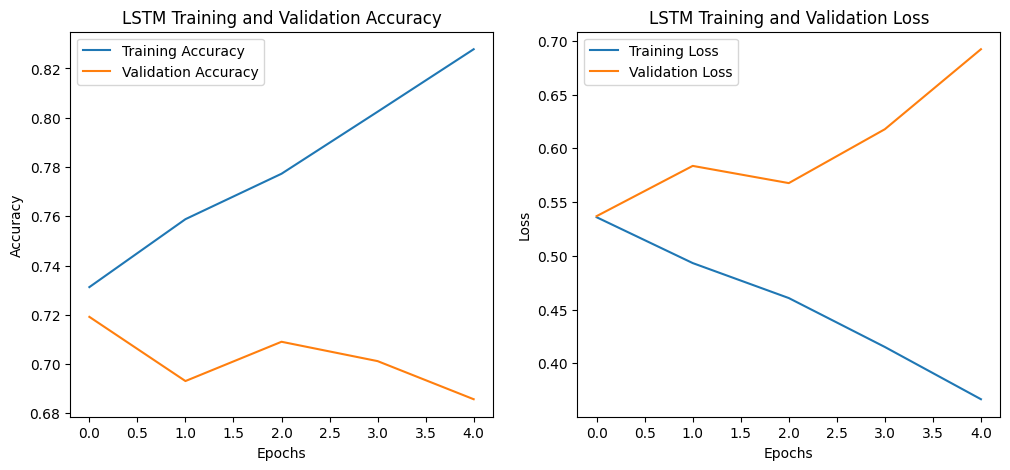

In [105]:
plt.figure(figsize=(12,5))
plt.subplot(1, 2, 1)
plt.plot(history_lstm.history['accuracy'], label='Training Accuracy')
plt.plot(history_lstm.history['val_accuracy'], label='Validation Accuracy')
plt.title('LSTM Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_lstm.history['loss'], label='Training Loss')
plt.plot(history_lstm.history['val_loss'], label='Validation Loss')
plt.title('LSTM Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.show()

In [106]:
def make_predictions_lstm(text):
    preprocessed_text = clean_tweet(text)
    sequence = tokenizer.texts_to_sequences([preprocessed_text])
    padded_sequence = pad_sequences(sequence, maxlen=100)
    prediction = model_lstm.predict(padded_sequence)
    sentiment = 'Positive' if prediction[0][0] >= 0.5 else 'Negative'
    return sentiment, prediction[0][0]

In [107]:
example_tweet = "I love this product! It works great and exceeded my expectations."
sentiment, confidence = make_predictions_lstm(example_tweet)
print(f"Tweet: {example_tweet}\nPredicted Sentiment: {sentiment} (Confidence: {confidence})")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 131ms/step
Tweet: I love this product! It works great and exceeded my expectations.
Predicted Sentiment: Positive (Confidence: 0.9404940605163574)


In [108]:
example_tweet = "I hate this product! It is terrible and a waste of money."
sentiment, confidence = make_predictions_lstm(example_tweet)
print(f"Tweet: {example_tweet}\nPredicted Sentiment: {sentiment} (Confidence: {confidence})")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
Tweet: I hate this product! It is terrible and a waste of money.
Predicted Sentiment: Negative (Confidence: 0.012577182613313198)


In [109]:
example_tweet = "I love being scamed by online sellers!"
sentiment, confidence = make_predictions_lstm(example_tweet)
print(f"Tweet: {example_tweet}\nPredicted Sentiment: {sentiment} (Confidence: {confidence})")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
Tweet: I love being scamed by online sellers!
Predicted Sentiment: Positive (Confidence: 0.9615808725357056)


We can see that the LSTM model performs better than the FFNN model, achieving around 82% accuracy on the validation set after 5 epochs. Negative tweets are predicted with higher confidence compared to the FFNN model. However, irony is still not detected correctly.

### 6.3 Pre-trained BERT model

We will use the pre-trained BERT model from the `transformers` library to perform sentiment analysis. BERT is a powerful language model that has been pre-trained on a large corpus of text data and can be fine-tuned for specific tasks like sentiment analysis.

We will use the model from [TweetEval](https://huggingface.co/cardiffnlp/twitter-roberta-base-sentiment-latest) which is a RoBERTa model fine-tuned for sentiment analysis on Twitter data.

Labels: 0 -> Negative; 1 -> Neutral; 2 -> Positive

In [110]:
from transformers import pipeline

MODEL = "cardiffnlp/twitter-roberta-base-sentiment-latest"
sentiment_task = pipeline("sentiment-analysis", model=MODEL, tokenizer=MODEL)

config.json:   0%|          | 0.00/929 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/501M [00:00<?, ?B/s]

Some weights of the model checkpoint at cardiffnlp/twitter-roberta-base-sentiment-latest were not used when initializing RobertaForSequenceClassification: ['roberta.pooler.dense.bias', 'roberta.pooler.dense.weight']
- This IS expected if you are initializing RobertaForSequenceClassification from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing RobertaForSequenceClassification from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).


vocab.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/501M [00:00<?, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

Device set to use cpu


In [111]:
example_tweet = "I love this product! It works great and exceeded my expectations."
sentiment_task(example_tweet)

[{'label': 'positive', 'score': 0.9911432266235352}]

In [112]:
example_tweet = "I hate this product! It is terrible and a waste of money."
sentiment_task(example_tweet)

[{'label': 'negative', 'score': 0.9533916711807251}]

In [113]:
example_tweet = "I love being scamed by online sellers!"
sentiment_task(example_tweet)

[{'label': 'negative', 'score': 0.4545850157737732}]

The pre-trained BERT model can accurately predict the sentiment of tweets, including positive, negative, and neutral sentiments. It leverages the power of transformer architectures to capture complex language patterns and context. It even detects irony.

> It is possible to train BERT from scratch, but it requires a massive amount of data and computational resources. Pre-trained models are typically fine-tuned for specific tasks, which is more efficient and effective for most applications.

### 6.4 FFNN vs LSTM
Let's compare the performance of the FFNN and LSTM models on some example tweets looking at the confusion matrix.

1314/1314 ━━━━━━━━━━━━━━━━━━━━ 1s 648us/step


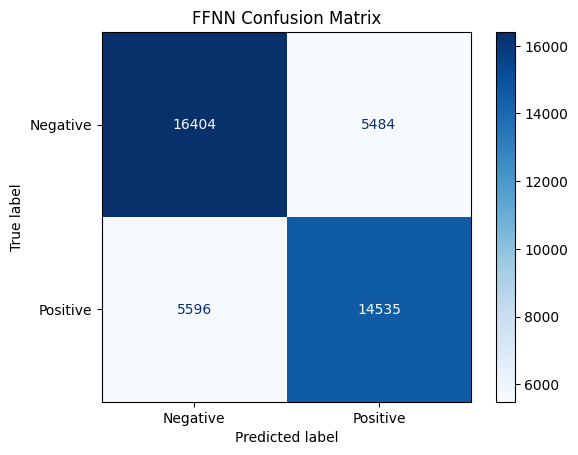

1314/1314 ━━━━━━━━━━━━━━━━━━━━ 20s 15ms/step


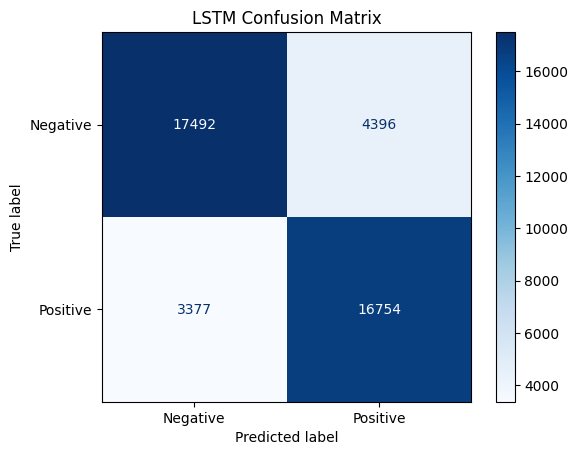

In [114]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

y_pred_ffnn = (model_ffnn.predict(X) >= 0.5).astype(int)
cm_ffnn = confusion_matrix(y, y_pred_ffnn)
disp_ffnn = ConfusionMatrixDisplay(confusion_matrix=cm_ffnn, display_labels=['Negative', 'Positive'])
disp_ffnn.plot(cmap=plt.cm.Blues)
plt.title('FFNN Confusion Matrix')
plt.show()

y_pred_lstm = (model_lstm.predict(X) >= 0.5).astype(int)
cm_lstm = confusion_matrix(y, y_pred_lstm)
disp_lstm = ConfusionMatrixDisplay(confusion_matrix=cm_lstm, display_labels=['Negative', 'Positive'])
disp_lstm.plot(cmap=plt.cm.Blues)
plt.title('LSTM Confusion Matrix')
plt.show()

We confirm apart from accuracy that LSTM outperforms FFNN in all metrics after looking at the confusion matrix.